# CISC3024 AI Assignment #1 — Error Analysis (Stage 5)
## "I ran a model" -> "I understand what the model gets wrong"

This notebook turns a single test-accuracy number into the analysis that actually
earns marks. It works against **any** run you have trained — the main run or any
ablation — because it reads that run's `results.json` for the configuration and
its `best.pt` for the weights.

### What it produces
| Output | Why it matters |
|--------|----------------|
| Normalised confusion matrix | which classes bleed into which |
| Top-10 confused class pairs | a ranked, quotable list of failure modes |
| **Error gallery** — 16 most confidently-wrong images | the headline figure of any report |
| Confidence histogram (correct vs wrong) | is the model over-confident? |
| Accuracy vs confidence threshold | how much accuracy you gain by abstaining |
| Per-class precision / recall / F1 | exposes classes that are quietly failing |
| `misclassified.csv` | every wrong test prediction, with confidence |

### To analyse a different run
Change `ANALYSE_TAG` in the first cell to any folder name under
`MyDrive/cisc3024_ai1/runs/`, e.g. `abl_01_resnet18`, `abl_04_freeze_backbone`.

> **Note on the test set.** This notebook reads the held-out test set. That is
> correct here — you are *describing* a frozen model, not selecting one. Do not
> use these numbers to pick a checkpoint.


## Stage 5 — Configuration

In [1]:
# =============================================================================
# Which run to analyse, and where everything lives
# =============================================================================
ANALYSE_TAG = "mnv4_cifar10"     # or "abl_01_resnet18", "abl_03_img128", ...

import os, sys, json, gc, contextlib
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torchvision
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import timm
from sklearn.metrics import confusion_matrix, classification_report

# --- Google Drive -----------------------------------------------------------
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    from google.colab import drive
    if not os.path.ismount("/content/drive"):
        drive.mount("/content/drive")
    DRIVE_ROOT = "/content/drive/MyDrive/cisc3024_ai1"
else:
    DRIVE_ROOT = os.path.abspath("./cisc3024_ai1")

DATA_DIR  = os.path.join(DRIVE_ROOT, "data")
RUNS_ROOT = os.path.join(DRIVE_ROOT, "runs")
RUN_DIR   = os.path.join(RUNS_ROOT, ANALYSE_TAG)

RESULT_JSON = os.path.join(RUN_DIR, "results.json")
BEST_CKPT   = os.path.join(RUN_DIR, "best.pt")

print("analysing run :", ANALYSE_TAG)
print("run dir       :", RUN_DIR)
print("results.json  :", "found" if os.path.isfile(RESULT_JSON) else "MISSING")
print("best.pt       :", "found" if os.path.isfile(BEST_CKPT) else "MISSING")

# --- fail fast, and say what IS available -----------------------------------
# Without this you get a bare FileNotFoundError 40 cells later, or worse, a
# KeyError from a stale results.json. Listing the runs on Drive turns a dead end
# into a one-line fix.
if not os.path.isdir(RUNS_ROOT):
    raise FileNotFoundError(
        f"{RUNS_ROOT} does not exist -- is Google Drive mounted?")
available = sorted(d for d in os.listdir(RUNS_ROOT)
                   if os.path.isdir(os.path.join(RUNS_ROOT, d)))
for _p in (RESULT_JSON, BEST_CKPT):
    if not os.path.isfile(_p):
        raise FileNotFoundError(
            f"missing {os.path.basename(_p)} for ANALYSE_TAG={ANALYSE_TAG!r}\n"
            f"  looked in : {RUN_DIR}\n"
            f"  available : {available}")
print("available runs:", available)

Mounted at /content/drive
analysing run : mnv4_cifar10
run dir       : /content/drive/MyDrive/cisc3024_ai1/runs/mnv4_cifar10
results.json  : found
best.pt       : found
available runs: ['abl_01_resnet18', 'abl_02_mnv4_medium', 'abl_03_img128', 'abl_04_freeze_backbone', 'mnv4_cifar10']


## Stage 5 — Rebuild the model exactly as it was trained

The configuration comes from the run's own `results.json`, so the test-time
pre-processing matches training. If it did not, your accuracy would be measured
under a different input distribution and the whole analysis would be wrong.


In [2]:
with open(RESULT_JSON) as f:
    RES = json.load(f)

# --- schema normalisation ----------------------------------------------------
# TWO different notebooks write results.json, and they do not agree:
#   * the main run notebook  -> {"test_acc", "best_val_acc", "epochs_run",
#                                "history", "cfg"}                        (5 keys)
#   * the ablation notebook  -> the same PLUS "tag", "freeze_backbone",
#                               "freeze_mode", "total_params",
#                               "trainable_params", "sec_per_epoch_mean", ...
# Indexing a key that only the ablation schema has therefore raises KeyError
# when you analyse the main run. Read through one merged view with defaults
# instead of assuming either schema.
CFG = dict(RES.get("cfg", {}))
RUN = {**CFG, **{k: v for k, v in RES.items() if k != "cfg"}}
RUN.setdefault("tag", ANALYSE_TAG)
RUN.setdefault("freeze_backbone", False)   # the main run never freezes anything
RUN.setdefault("freeze_mode", None)

IMG_SIZE  = RUN["img_size"]
BATCH     = 256
NUM_WORK  = 2
MEAN, STD = (0.485, 0.456, 0.406), (0.229, 0.224, 0.225)
RESIZE    = int(round(IMG_SIZE * 256 / 224))

_schema = "ablation" if "freeze_backbone" in RES else "main run"
print(f"results.json  : {_schema} schema, {len(RES)} top-level keys")
print(json.dumps({k: RUN.get(k) for k in
                  ("tag", "model_name", "img_size", "freeze_backbone",
                   "freeze_mode", "total_params", "trainable_params")},
                 indent=2))
print(f"recorded test acc in results.json: {RES['test_acc']:.4f}")

# eval transform must match the one used during training
eval_tf = transforms.Compose([
    transforms.Resize(RESIZE),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])


class IndexedTest(Dataset):
    """Keeps the dataset order, so index i here == index i in the logits tensor."""
    def __init__(self, base, tf):
        self.base, self.tf = base, tf
    def __len__(self):
        return len(self.base)
    def __getitem__(self, i):
        img, y = self.base[i]
        return self.tf(img), y


base_test = datasets.CIFAR10(DATA_DIR, train=False, download=True, transform=None)
test_set  = IndexedTest(base_test, eval_tf)
test_loader = DataLoader(test_set, batch_size=BATCH, shuffle=False,
                         num_workers=NUM_WORK, pin_memory=True)
CLASSES = base_test.classes
print("test set:", len(test_set), "images |", len(CLASSES), "classes")

# --- rebuild the architecture and load the trained weights -------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def build_model(name, num_classes=10):
    try:
        return timm.create_model(name, pretrained=False, num_classes=num_classes)
    except Exception:
        return timm.create_model(name.split(".")[0], pretrained=False,
                                 num_classes=num_classes)

model = build_model(RUN["model_name"], RUN["num_classes"]).to(device)
try:
    ckpt = torch.load(BEST_CKPT, map_location=device, weights_only=False)
except TypeError:
    ckpt = torch.load(BEST_CKPT, map_location=device)
model.load_state_dict(ckpt["model"])
model.eval()

print(f"loaded best.pt from epoch {ckpt['epoch']} "
      f"(val acc {ckpt.get('best_acc', float('nan')):.4f})")

USE_AMP = torch.cuda.is_available()
def autocast_ctx():
    return torch.amp.autocast("cuda", dtype=torch.float16, enabled=USE_AMP)

n_params = sum(p.numel() for p in model.parameters())
print(f"parameters: {n_params/1e6:.3f} M")

results.json  : main run schema, 5 top-level keys
{
  "tag": "mnv4_cifar10",
  "model_name": "mobilenetv4_conv_small.e2400_r224_in1k",
  "img_size": 224,
  "freeze_backbone": false,
  "freeze_mode": null,
  "total_params": null,
  "trainable_params": null
}
recorded test acc in results.json: 0.9631
test set: 10000 images | 10 classes
loaded best.pt from epoch 11 (val acc 0.9670)
parameters: 2.506 M


## Stage 5 — Collect predictions

Logits are kept in full (not just the argmax) because confidence is half the
story: *how wrong* the model is matters as much as *how often*.


In [3]:
@torch.no_grad()
def collect_logits(model, loader, device):
    model.eval()
    logits_all, targets_all = [], []
    for images, targets in loader:
        with autocast_ctx():
            out = model(images.to(device, non_blocking=True))
        logits_all.append(out.float().cpu())
        targets_all.append(targets)
    return torch.cat(logits_all), torch.cat(targets_all)


logits, targets = collect_logits(model, test_loader, device)
probs = torch.softmax(logits, dim=1)
conf, pred = probs.max(dim=1)

correct = pred.eq(targets)
acc = correct.float().mean().item()

# top-5
top5 = logits.topk(5, dim=1).indices
top5_acc = top5.eq(targets.view(-1, 1)).any(dim=1).float().mean().item()

print(f"top-1 accuracy : {acc:.4f}   (results.json said {RES['test_acc']:.4f})")
print(f"top-5 accuracy : {top5_acc:.4f}")
print(f"errors         : {(~correct).sum().item()} / {len(targets)}")
print(f"mean confidence on correct : {conf[correct].mean():.4f}")
print(f"mean confidence on wrong   : {conf[~correct].mean():.4f}")

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


top-1 accuracy : 0.9633   (results.json said 0.9631)
top-5 accuracy : 0.9984
errors         : 367 / 10000
mean confidence on correct : 0.8885
mean confidence on wrong   : 0.6217


## Stage 5 — Confusion matrix and per-class metrics

The **row-normalised** matrix is the useful one: each row sums to 100 %, so you
read "of all true *cat* images, what fraction went where". The raw counts matrix
hides class imbalance; CIFAR-10 is balanced, so the two agree closely here — but
get into the habit of normalising.


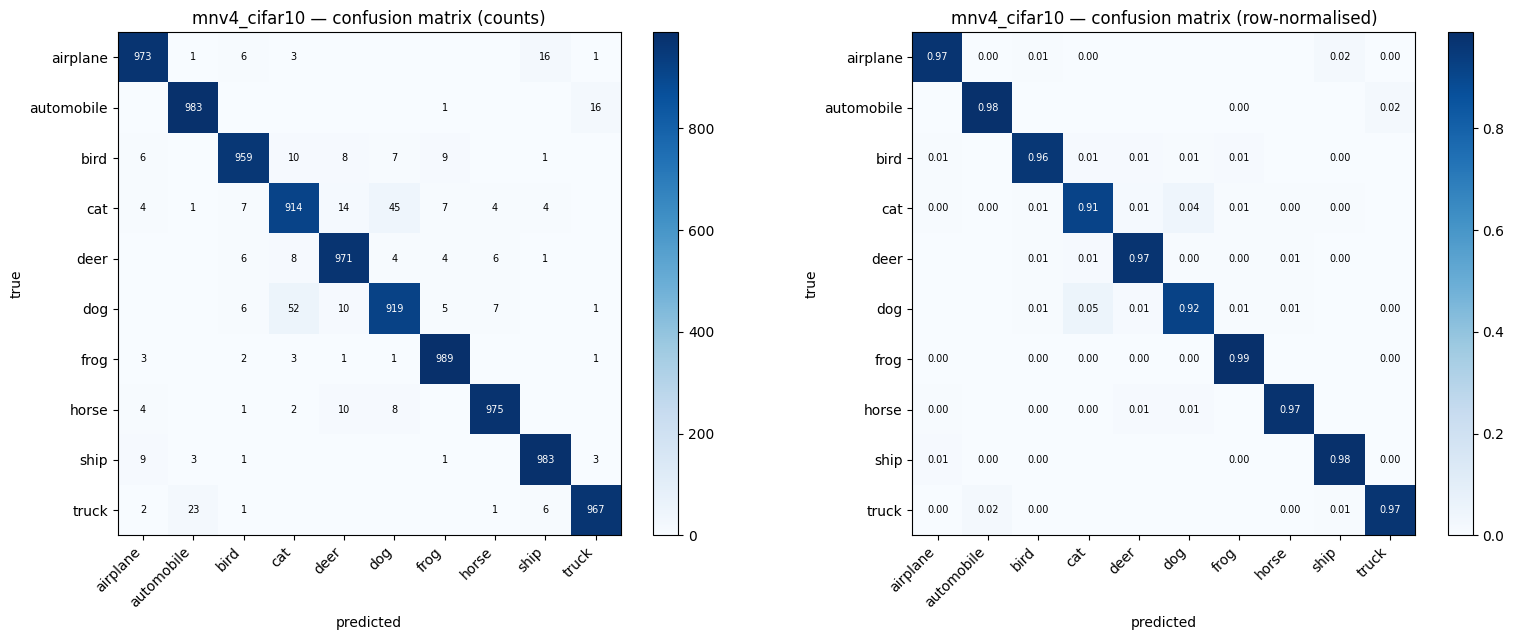

              precision    recall  f1-score   support

    airplane     0.9720    0.9730    0.9725      1000
  automobile     0.9723    0.9830    0.9776      1000
        bird     0.9697    0.9590    0.9643      1000
         cat     0.9214    0.9140    0.9177      1000
        deer     0.9576    0.9710    0.9643      1000
         dog     0.9339    0.9190    0.9264      1000
        frog     0.9734    0.9890    0.9812      1000
       horse     0.9819    0.9750    0.9784      1000
        ship     0.9723    0.9830    0.9776      1000
       truck     0.9778    0.9670    0.9723      1000

    accuracy                         0.9633     10000
   macro avg     0.9632    0.9633    0.9632     10000
weighted avg     0.9632    0.9633    0.9632     10000



In [4]:
cm      = confusion_matrix(targets.numpy(), pred.numpy())
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
for ax, mat, title, fmt in (
        (axes[0], cm,      "counts",       "d"),
        (axes[1], cm_norm, "row-normalised", ".2f")):
    im = ax.imshow(mat, cmap="Blues")
    ax.set_xticks(range(10)); ax.set_xticklabels(CLASSES, rotation=45, ha="right")
    ax.set_yticks(range(10)); ax.set_yticklabels(CLASSES)
    ax.set_xlabel("predicted"); ax.set_ylabel("true")
    ax.set_title(f"{ANALYSE_TAG} — confusion matrix ({title})")
    vmax = mat.max()
    for i in range(10):
        for j in range(10):
            if mat[i, j] > 0:
                ax.text(j, i, format(mat[i, j], fmt), ha="center", va="center",
                        fontsize=7,
                        color="white" if mat[i, j] > vmax * 0.5 else "black")
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.savefig(os.path.join(RUN_DIR, "error_confusion_matrix.png"), dpi=140)
plt.show()

print(classification_report(targets.numpy(), pred.numpy(),
                            target_names=CLASSES, digits=4))

## Stage 5 — Ranked failure modes: the top-10 confused pairs

Off-diagonal mass, sorted. This is the single most quotable table in the report —
it names the specific confusions rather than hand-waving about "some errors".


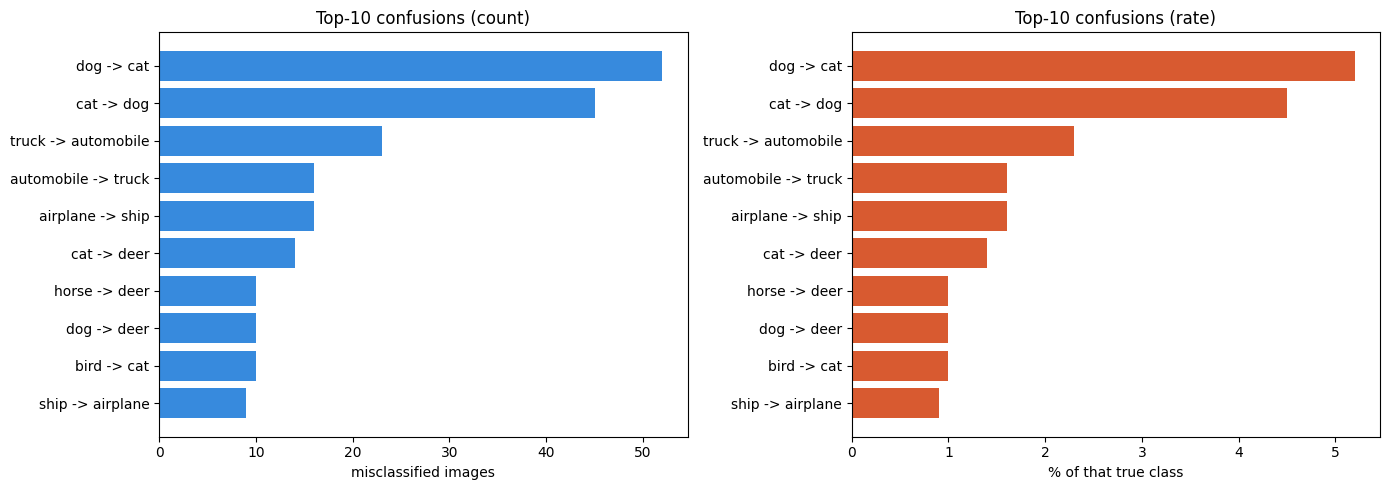

          true -> pred |  count |  % of true class
----------------------------------------------------
            dog -> cat |     52 |            5.20%
            cat -> dog |     45 |            4.50%
   truck -> automobile |     23 |            2.30%
   automobile -> truck |     16 |            1.60%
      airplane -> ship |     16 |            1.60%
           cat -> deer |     14 |            1.40%
         horse -> deer |     10 |            1.00%
           dog -> deer |     10 |            1.00%
           bird -> cat |     10 |            1.00%
      ship -> airplane |      9 |            0.90%


In [5]:
pairs = []
for i in range(10):            # true
    for j in range(10):        # predicted
        if i != j and cm[i, j] > 0:
            pairs.append((cm[i, j], cm_norm[i, j], CLASSES[i], CLASSES[j]))
pairs.sort(reverse=True)
top_pairs = pairs[:10]

labels = [f"{t} -> {p}" for _, _, t, p in top_pairs]
counts = [c for c, _, _, _ in top_pairs]
rates  = [r for _, r, _, _ in top_pairs]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
y = np.arange(len(labels))[::-1]
axes[0].barh(y, counts, color="#378ADD")
axes[0].set_yticks(y); axes[0].set_yticklabels(labels)
axes[0].set_xlabel("misclassified images"); axes[0].set_title("Top-10 confusions (count)")
axes[1].barh(y, [r * 100 for r in rates], color="#D85A30")
axes[1].set_yticks(y); axes[1].set_yticklabels(labels)
axes[1].set_xlabel("% of that true class"); axes[1].set_title("Top-10 confusions (rate)")
plt.tight_layout()
plt.savefig(os.path.join(RUN_DIR, "error_top_confusions.png"), dpi=140)
plt.show()

print(f"{'true -> pred':>22} | {'count':>6} | {'% of true class':>16}")
print("-" * 52)
for c, r, t, p in top_pairs:
    print(f"{t + ' -> ' + p:>22} | {c:6d} | {r*100:15.2f}%")

## Stage 5 — The error gallery

The 16 test images the model got wrong **while being most confident**. These are
the informative errors: a low-confidence mistake is forgivable, a confident one
reveals a genuine blind spot. Look at them and describe what you actually see —
blurry subjects, ambiguous silhouettes, unusual poses.

For each image the title shows `true -> predicted` and the model's confidence.


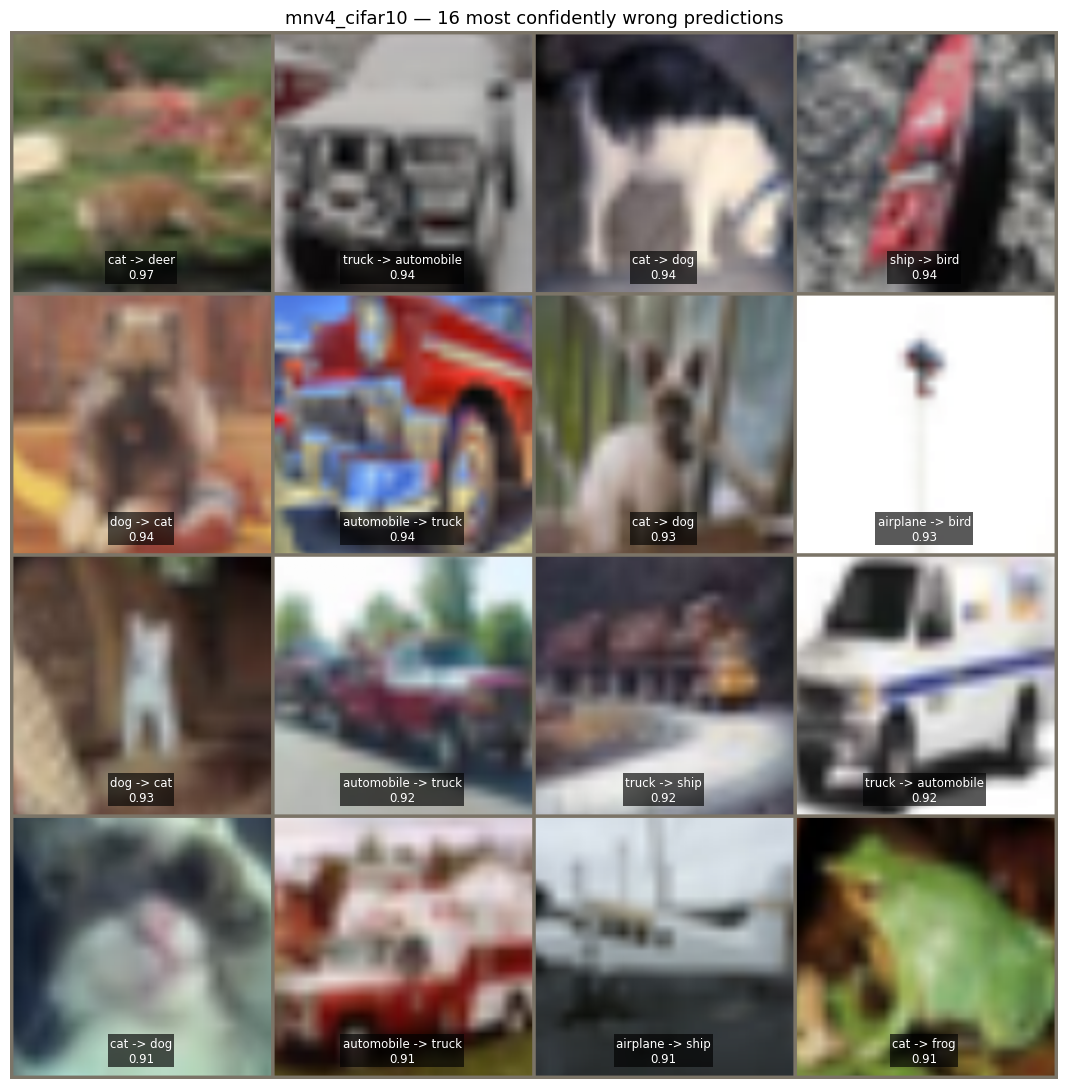

Gallery (most confident errors):
   1. test idx  4965 | true        cat | pred       deer | conf 0.9675
   2. test idx  4276 | true      truck | pred automobile | conf 0.9430
   3. test idx  8281 | true        cat | pred        dog | conf 0.9385
   4. test idx  1685 | true       ship | pred       bird | conf 0.9374
   5. test idx  8589 | true        dog | pred        cat | conf 0.9367
   6. test idx  7892 | true automobile | pred      truck | conf 0.9355
   7. test idx  4614 | true        cat | pred        dog | conf 0.9346
   8. test idx  3444 | true   airplane | pred       bird | conf 0.9299
   9. test idx  4740 | true        dog | pred        cat | conf 0.9294
  10. test idx  9227 | true automobile | pred      truck | conf 0.9207
  11. test idx  2495 | true      truck | pred       ship | conf 0.9201
  12. test idx  5416 | true      truck | pred automobile | conf 0.9160
  13. test idx  9148 | true        cat | pred        dog | conf 0.9133
  14. test idx  3560 | true automobile | pre

In [6]:
wrong_idx = torch.nonzero(~correct).squeeze(1)
order = conf[wrong_idx].argsort(descending=True)
gallery = wrong_idx[order][:16].tolist()

# fetch only the images we need (the test set is 10 000 images — don't hold it all)
imgs = torch.stack([test_set[i][0] for i in gallery])
grid = torchvision.utils.make_grid(imgs, nrow=4, padding=3)
grid = grid * torch.tensor(STD).view(3, 1, 1) + torch.tensor(MEAN).view(3, 1, 1)

fig, ax = plt.subplots(figsize=(11, 11))
ax.imshow(grid.permute(1, 2, 0).clamp(0, 1))
ax.axis("off")
ax.set_title(f"{ANALYSE_TAG} — 16 most confidently wrong predictions", fontsize=13)

# annotate each tile
tile = grid.shape[1] // 4
for k, idx in enumerate(gallery):
    r, c = divmod(k, 4)
    t = targets[idx].item(); p = pred[idx].item()
    ax.text(c * tile + tile / 2, r * tile + tile - 10,
            f"{CLASSES[t]} -> {CLASSES[p]}\n{conf[idx]:.2f}",
            ha="center", va="bottom", fontsize=8.5, color="white",
            bbox=dict(facecolor="black", alpha=0.65, pad=1.6, edgecolor="none"))
plt.tight_layout()
plt.savefig(os.path.join(RUN_DIR, "error_gallery.png"), dpi=140)
plt.show()

print("Gallery (most confident errors):")
for k, idx in enumerate(gallery):
    t = targets[idx].item(); p = pred[idx].item()
    print(f"  {k+1:2d}. test idx {idx:5d} | true {CLASSES[t]:>10s} | "
          f"pred {CLASSES[p]:>10s} | conf {conf[idx]:.4f}")

## Stage 5 — Is the model over-confident?

A well-calibrated model that says 0.9 should be right about 90 % of the time.
Comparing the confidence distribution for correct vs wrong predictions, plus the
accuracy you would get by abstaining below a threshold, tells you whether the
softmax scores can be trusted — which matters if you ever deploy this.


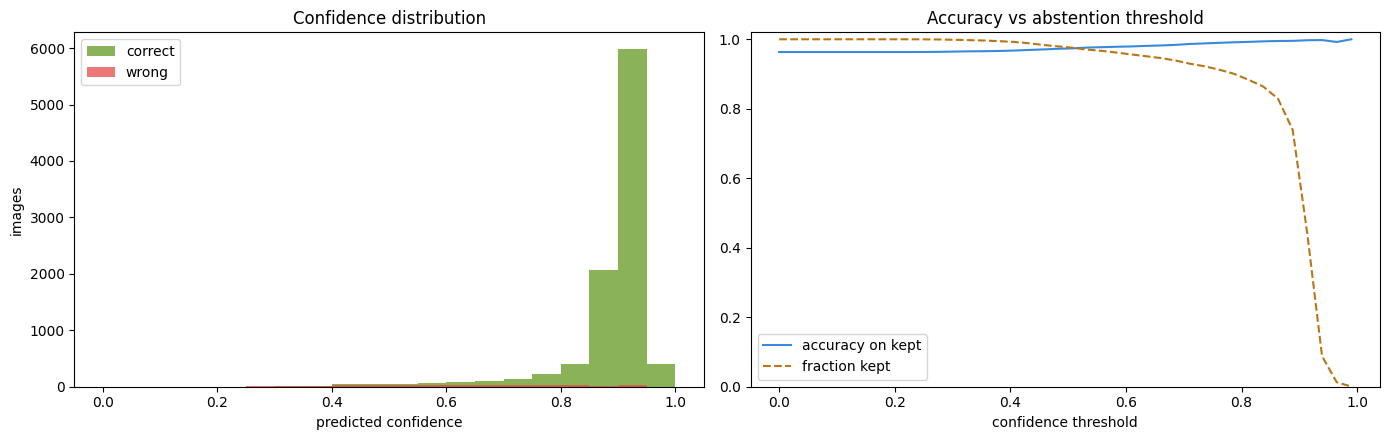

  confidence bin |      n | actual accuracy
--------------------------------------------
0.2-0.3          |     12 |           8.33%
0.3-0.4          |     60 |          48.33%
0.4-0.5          |    155 |          59.35%
0.5-0.6          |    190 |          68.42%
0.6-0.7          |    245 |          73.06%
0.7-0.8          |    419 |          85.20%
0.8-0.9          |   2513 |          98.05%
0.9-1.0          |   6406 |          99.61%


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

bins = np.linspace(0, 1, 21)
axes[0].hist(conf[correct].numpy(),  bins=bins, alpha=0.75, label="correct", color="#639922")
axes[0].hist(conf[~correct].numpy(), bins=bins, alpha=0.75, label="wrong",   color="#E24B4A")
axes[0].set_xlabel("predicted confidence"); axes[0].set_ylabel("images")
axes[0].set_title("Confidence distribution"); axes[0].legend()

thresholds = np.linspace(0.0, 0.99, 40)
kept_acc, kept_frac = [], []
for th in thresholds:
    keep = conf >= th
    kept_frac.append(keep.float().mean().item())
    kept_acc.append(correct[keep].float().mean().item() if keep.any() else np.nan)
axes[1].plot(thresholds, kept_acc, color="#378ADD", label="accuracy on kept")
axes[1].plot(thresholds, kept_frac, color="#BA7517", linestyle="--", label="fraction kept")
axes[1].set_xlabel("confidence threshold"); axes[1].set_ylim(0, 1.02)
axes[1].set_title("Accuracy vs abstention threshold"); axes[1].legend()
plt.tight_layout()
plt.savefig(os.path.join(RUN_DIR, "error_calibration.png"), dpi=140)
plt.show()

# reliability: does "0.9 confident" actually mean 90% correct?
print(f"{'confidence bin':>16} | {'n':>6} | {'actual accuracy':>15}")
print("-" * 44)
for lo in np.arange(0.0, 1.0, 0.1):
    m = (conf >= lo) & (conf < lo + 0.1)
    if m.sum() > 0:
        print(f"{lo:.1f}-{lo+0.1:.1f}{'':>9} | {m.sum().item():6d} | "
              f"{correct[m].float().mean().item()*100:14.2f}%")

## Stage 5 — Export the misclassified samples

A CSV you can sort and quote from while writing the report.


In [8]:
import csv

csv_path = os.path.join(RUN_DIR, "misclassified.csv")
mis = torch.nonzero(~correct).squeeze(1).tolist()
with open(csv_path, "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["test_index", "true_class", "predicted_class",
                "confidence", "true_class_prob", "runner_up_class",
                "runner_up_prob", "top5_contains_true"])
    for i in mis:
        t, p = targets[i].item(), pred[i].item()
        row_probs = probs[i]
        order_i = row_probs.argsort(descending=True)
        runner = order_i[1].item()
        w.writerow([i, CLASSES[t], CLASSES[p],
                    f"{conf[i]:.4f}", f"{row_probs[t]:.4f}",
                    CLASSES[runner], f"{row_probs[runner]:.4f}",
                    bool(t in top5[i].tolist())])

print(f"wrote {len(mis)} misclassified samples -> {csv_path}")

# summary block you can paste straight into the report
summary = {
    "run": ANALYSE_TAG,
    "top1_acc": round(acc, 4),
    "top5_acc": round(top5_acc, 4),
    "n_errors": int((~correct).sum()),
    "mean_conf_correct": round(conf[correct].mean().item(), 4),
    "mean_conf_wrong": round(conf[~correct].mean().item(), 4),
    "worst_class_recall": CLASSES[int(cm_norm.diagonal().argmin())],
    "worst_class_recall_value": round(float(cm_norm.diagonal().min()), 4),
    "best_class_recall": CLASSES[int(cm_norm.diagonal().argmax())],
    "best_class_recall_value": round(float(cm_norm.diagonal().max()), 4),
    "top3_confusions": [f"{t}->{p} ({c})" for c, _, t, p in top_pairs[:3]],
}
with open(os.path.join(RUN_DIR, "error_summary.json"), "w") as f:
    json.dump(summary, f, indent=2)

print()
print(json.dumps(summary, indent=2))

# free GPU memory
del model
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

wrote 367 misclassified samples -> /content/drive/MyDrive/cisc3024_ai1/runs/mnv4_cifar10/misclassified.csv

{
  "run": "mnv4_cifar10",
  "top1_acc": 0.9633,
  "top5_acc": 0.9984,
  "n_errors": 367,
  "mean_conf_correct": 0.8885,
  "mean_conf_wrong": 0.6217,
  "worst_class_recall": "cat",
  "worst_class_recall_value": 0.914,
  "best_class_recall": "frog",
  "best_class_recall_value": 0.989,
  "top3_confusions": [
    "dog->cat (52)",
    "cat->dog (45)",
    "truck->automobile (23)"
  ]
}


## How to write this up

Five things to take from this notebook into the report:

1. **Name the failure modes concretely.** Not "the model makes some errors" but
   "the largest single confusion is *cat -> dog*, accounting for N errors (X % of
   all true cats)" — that comes from the ranked pair table.

2. **Show the gallery and describe what you see.** Two or three sentences about
   the actual images (blur, ambiguous silhouette, unusual viewpoint) is worth more
   than any statistic here.

3. **Report top-1 *and* top-5.** If top-5 is much higher, the model usually ranks
   the right answer highly — that is a different and more useful statement than
   "it is wrong".

4. **Comment on calibration.** If mean confidence on wrong predictions is high
   (say > 0.6), the model is over-confident and the softmax scores should not be
   used as a reliability signal.

5. **Compare across runs.** Re-run this notebook with `ANALYSE_TAG` set to
   `abl_01_resnet18`, `abl_03_img128` and `abl_04_freeze_backbone`. Does the
   frozen model fail on the *same* images as the full fine-tune, or different
   ones? That comparison is the strongest possible evidence that your ablation
   actually changed something meaningful — and it is the kind of observation that
   distinguishes a good report from a table of numbers.
